# Robust Scaling

Robust Scaling is a feature scaling technique that uses the **median** and **Interquartile Range (IQR)** instead of the mean and standard deviation.

It is particularly useful when numerical features contain **outliers**.

The formula is:

x_scaled = (x - Median) / IQR

Where:

- x = Original value
- Median = Median of the feature
- IQR = Q3 - Q1

Because median and IQR are less affected by extreme values, Robust Scaling is more resistant to outliers than Standardization and Min-Max Scaling.

## Why Do We Need Robust Scaling?

Consider the following values:

10, 20, 30, 40, 50, 1000

The value `1000` is an extreme value.

Mean and standard deviation can be strongly affected by this outlier.

Robust Scaling uses:

- Median
- IQR

These statistics are much less affected by extreme observations.

Therefore, Robust Scaling can be useful for datasets containing significant outliers.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Age": [20, 22, 25, 28, 30, 32, 35, 80],
    "Salary": [25000, 30000, 35000, 40000, 45000, 50000, 60000, 500000]
})

df

,Age,Salary
0,20,25000
1,22,30000
2,25,35000
3,28,40000
4,30,45000
5,32,50000
6,35,60000
7,80,500000


## Visualizing the Outliers

Before applying Robust Scaling, let's visualize the data.

The large values in Age and Salary represent potential outliers.

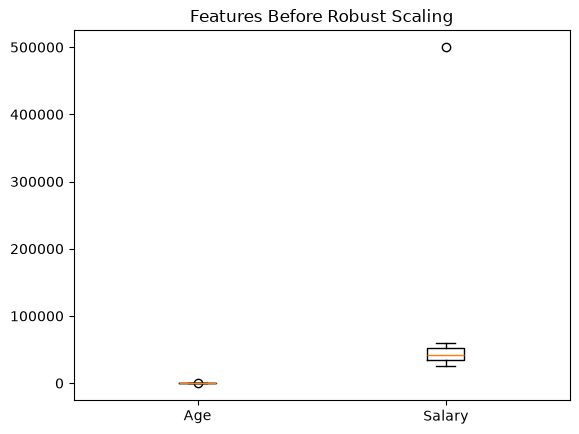

In [2]:
import matplotlib.pyplot as plt

plt.boxplot(df)

plt.title("Features Before Robust Scaling")
plt.xticks(
    range(1, len(df.columns) + 1),
    df.columns
)

plt.show()

## Median and IQR

Robust Scaling uses two important statistics:

### Median

The median is the middle value of an ordered dataset.

### IQR

The Interquartile Range represents the middle 50% of the data.

Formula:

IQR = Q3 - Q1

Where:

- Q1 = 25th percentile
- Q3 = 75th percentile

In [3]:
for column in df.columns:
    
    median = df[column].median()
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    print(f"{column}")
    print("Median:", median)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print()

Age
Median: 29.0
Q1: 24.25
Q3: 32.75
IQR: 8.5

Salary
Median: 42500.0
Q1: 33750.0
Q3: 52500.0
IQR: 18750.0



## Manual Robust Scaling

The formula is:

x_scaled = (x - Median) / IQR

Steps:

1. Calculate the median.
2. Calculate Q1.
3. Calculate Q3.
4. Calculate the IQR.
5. Subtract the median from each observation.
6. Divide by the IQR.

In [4]:
df_manual = df.copy()

for column in df.columns:
    
    median = df[column].median()
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    df_manual[column] = (
        (df[column] - median) / IQR
    )

df_manual

,Age,Salary
0,-1.058824,-0.933333
1,-0.823529,-0.666667
2,-0.470588,-0.400000
3,-0.117647,-0.133333
4,0.117647,0.133333
5,0.352941,0.400000
6,0.705882,0.933333
7,6.000000,24.400000


## Using Scikit-Learn

Scikit-learn provides `RobustScaler` for performing Robust Scaling.

It automatically calculates the median and IQR and transforms the features.

In [5]:
from sklearn.preprocessing import RobustScaler

In [6]:
scaler = RobustScaler()

df_robust = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_robust

,Age,Salary
0,-1.058824,-0.933333
1,-0.823529,-0.666667
2,-0.470588,-0.400000
3,-0.117647,-0.133333
4,0.117647,0.133333
5,0.352941,0.400000
6,0.705882,0.933333
7,6.000000,24.400000


In [7]:
print("Median after scaling:")

print(df_robust.median())

Median after scaling:
Age       0.0
Salary    0.0
dtype: float64


In [8]:
print("Original Data:")
display(df)

print("\nRobust Scaled Data:")
display(df_robust)

Original Data:


,Age,Salary
0,20,25000
1,22,30000
2,25,35000
3,28,40000
4,30,45000
5,32,50000
6,35,60000
7,80,500000



Robust Scaled Data:


,Age,Salary
0,-1.058824,-0.933333
1,-0.823529,-0.666667
2,-0.470588,-0.400000
3,-0.117647,-0.133333
4,0.117647,0.133333
5,0.352941,0.400000
6,0.705882,0.933333
7,6.000000,24.400000
